# 线性模型

> y = w * x + b, 一般使用监督学习 supervised learning, 即数据分为训练集，开发集，测试集。训练集的输入有对应的输出结果，而测试集只有输入

假设目前有一组x,y
x = [1,2,3]
y = [2,4,6]
那输入x = 4时，y输出多少？

w = 0.0 loss = 4.0 loss = 16.0 loss = 36.0 mean loss = 18.666666666666668
w = 0.1 loss = 3.61 loss = 14.44 loss = 32.49 mean loss = 16.846666666666668
w = 0.2 loss = 3.24 loss = 12.96 loss = 29.160000000000004 mean loss = 15.120000000000003
w = 0.30000000000000004 loss = 2.8899999999999997 loss = 11.559999999999999 loss = 26.009999999999998 mean loss = 13.486666666666665
w = 0.4 loss = 2.5600000000000005 loss = 10.240000000000002 loss = 23.04 mean loss = 11.946666666666667
w = 0.5 loss = 2.25 loss = 9.0 loss = 20.25 mean loss = 10.5
w = 0.6000000000000001 loss = 1.9599999999999997 loss = 7.839999999999999 loss = 17.639999999999993 mean loss = 9.146666666666663
w = 0.7000000000000001 loss = 1.6899999999999995 loss = 6.759999999999998 loss = 15.209999999999999 mean loss = 7.886666666666666
w = 0.8 loss = 1.44 loss = 5.76 loss = 12.959999999999997 mean loss = 6.719999999999999
w = 0.9 loss = 1.2100000000000002 loss = 4.840000000000001 loss = 10.889999999999999 mean loss = 5.64666666666666

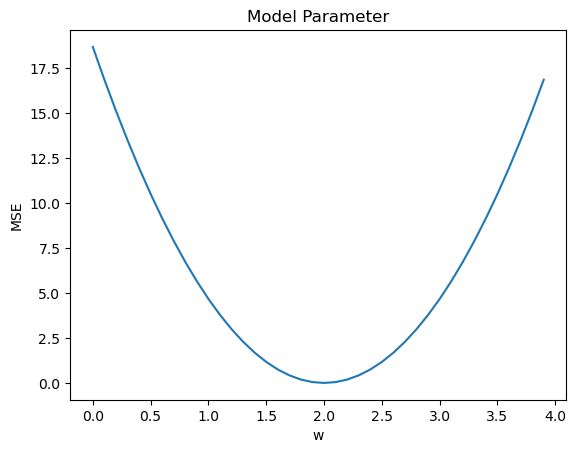

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,2,3],dtype = np.float32)
y = np.array([2,4,6],dtype = np.float32)

# model parameters
def forward(x,w):
    return x*w

# loss function
def loss(y,y_hat):
    return ((y_hat - y)**2)

w_list = []
mse_list = []

for w in np.arange(0,4,0.1):
    print(f"w = {w}", end = " ")
    l_sum = 0 # here could calculate the sum of losses for all samples
    for x_i, y_i in zip(x,y):
        y_hat = forward(x_i,w)
        l = loss(y_i, y_hat)
        l_sum += l
        print(f"loss = {l}" , end = " ")
    print(f"mean loss = {l_sum/len(x)}")
    w_list.append(w)
    mse_list.append(l_sum/len(x))

plt.plot(w_list, mse_list)
plt.xlabel('w')
plt.ylabel('MSE') # Mean Squared Error
plt.title('Model Parameter')
plt.show()

# 梯度下降

> 再上一个问题中，计算得出一个w值后，为了进一步使得cost最小，这成了优化算法，并引入梯度下降算法。

损失函数在某一点处的梯度 > 0,则可知其方向为增加，反之减少。所以我们可以通过计算损害函数的梯度 * 学习率(learning rate),来更新w

Epoch 1: w = 1.0933333333333333, cost = 4.666666666666667
Epoch 2: w = 1.1779555555555554, cost = 3.8362074074074086
Epoch 3: w = 1.2546797037037036, cost = 3.1535329869958857
Epoch 4: w = 1.3242429313580246, cost = 2.592344272332262
Epoch 5: w = 1.3873135910979424, cost = 2.1310222071581117
Epoch 6: w = 1.4444976559288012, cost = 1.7517949663820642
Epoch 7: w = 1.4963445413754464, cost = 1.440053319920117
Epoch 8: w = 1.5433523841804047, cost = 1.1837878313441108
Epoch 9: w = 1.5859728283235668, cost = 0.9731262101573632
Epoch 10: w = 1.6246153643467005, cost = 0.7999529948031382
Epoch 11: w = 1.659651263674342, cost = 0.6575969151946154
Epoch 12: w = 1.6914171457314033, cost = 0.5405738908195378
Epoch 13: w = 1.7202182121298057, cost = 0.44437576375991855
Epoch 14: w = 1.7463311789976905, cost = 0.365296627844598
Epoch 15: w = 1.7700069356245727, cost = 0.3002900634939416
Epoch 16: w = 1.7914729549662791, cost = 0.2468517784170642
Epoch 17: w = 1.8109354791694263, cost = 0.2029231330

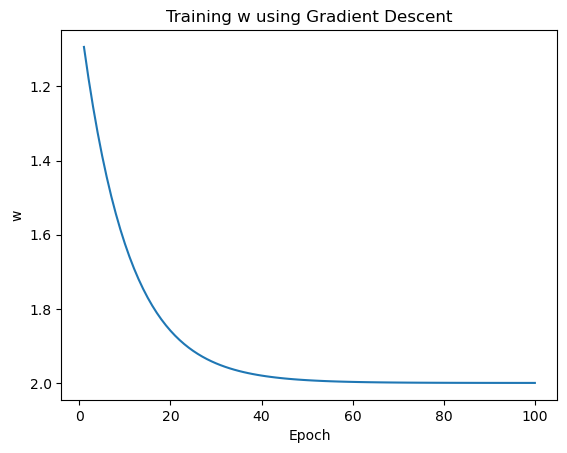

In [ ]:
w = 1.0
# calculate the cost for current w
def cost(x_l,y_l):
    cost_sum = 0
    for x_i, y_i in zip(x_l,y_l):
        y_hat = forward(x_i,w)
        cost_sum += loss(y_i, y_hat)
    return cost_sum/len(x_l)

# calculate the gradient for current w
def gradient(x_l,y_l):
    grad_sum = 0
    for x_i, y_i in zip(x_l,y_l):
        grad_sum += 2*x_i*(x_i*w - y_i) # the derivative of the cost function with respect to w 
    return grad_sum/len(x_l)

w_list.clear()
epochs = []
# training loop
for epoch in range(100):
    cost_val = cost(x,y)
    grad_val = gradient(x,y)
    w = w - 0.01*grad_val # update the parameter w using the gradient descent rule
    print(f"Epoch {epoch+1}: w = {w}, cost = {cost_val}")
    w_list.append(w)
    epochs.append(epoch+1)

plt.plot(epochs, w_list)
plt.xlabel('Epoch')
plt.ylabel('w')
plt.title('Training w using Gradient Descent')
plt.gca().invert_yaxis() # invert the y-axis to show the decrease of w over epochs
plt.show()

**可能的问题**：
    
    1. 学习率设置：太小收敛太慢，太大震荡不收敛

    2. 局部最优贪心算法

    3. 卡在鞍点: 随机梯度下降，小批量梯度下降（min-batch）

    4. 梯度消失: 多层网络链式求导，梯度越乘越小，底层参数不更新，模型根本学不动

    5. 梯度爆炸：梯度越乘越大，直接溢出

# 反向传播

> 一般神经网络计算图较为复杂，在进行前馈时便可将每一层输入计算其对某一方向上的梯度并存储，当一轮训练后得到loss便可进行逐层反馈(链式法则)对每层的输入权重进行调整。

但是如果每一层都只是对上一层输入的张量进行简单计算，那整个模型便可简化为一个简单计算。如果不用激活函数，不管神经网络叠多少层，都等价于一层线性模型，根本学不会复杂规律。激活函数就是为了引入 “**非线性**”，让网络能拟合任意复杂函数。可以拟合：曲线、复杂边界、任意复杂的真实世界分布

![img2](../img/backword_progration_2.png)

如上图，即为反向传播过程，试计算一下计算图的每个张量的梯度(-8)

![backword_progration_1.png](../img/backword_progration_1.png)

使用torch进行反向传播训练

In [5]:
import torch

x_data = [1.0,2.0,3.0]
y_data = [2.0,4.0,6.0]

w = torch.tensor([1.0])
w.requires_grad = True # need to calculate the gradient for w

# model prediction
def forward(x):
    return x*w

# loss function
def loss(y,y_hat):
    return ((y_hat - y)**2)

for epoch in range(200):
    print(f"Epoch {epoch+1}")
    for x,y in zip(x_data, y_data):
        y_hat = forward(x)
        l = loss(y, y_hat)
        l.backward() # compute the gradient for w backward propagation
        print(f"w = {w.item()}, loss = {l.item()}") # use .item() to get the value
        w.data.sub_(0.01 * w.grad.data) # update the parameter w using the gradient descent rule
        w.grad.data.zero_() # clear the gradient for the next step
        # use .data or .item() to avoid generate a new computational graph for w in each iteration

print(f"Final w: {w.item()}")

Epoch 1
w = 1.0, loss = 1.0
w = 1.0199999809265137, loss = 3.841600179672241
w = 1.0983999967575073, loss = 7.315943717956543
Epoch 2
w = 1.260688066482544, loss = 0.5465821623802185
w = 1.2754743099212646, loss = 2.099749803543091
w = 1.333436369895935, loss = 3.9987640380859375
Epoch 3
w = 1.4534177780151367, loss = 0.2987521290779114
w = 1.464349389076233, loss = 1.1476863622665405
w = 1.5072014331817627, loss = 2.1856532096862793
Epoch 4
w = 1.5959051847457886, loss = 0.16329261660575867
w = 1.6039870977401733, loss = 0.6273048520088196
w = 1.635668158531189, loss = 1.1946394443511963
Epoch 5
w = 1.7012479305267334, loss = 0.08925279974937439
w = 1.7072229385375977, loss = 0.34287363290786743
w = 1.7306450605392456, loss = 0.6529689431190491
Epoch 6
w = 1.779128909111023, loss = 0.048784039914608
w = 1.7835463285446167, loss = 0.18740876019001007
w = 1.8008626699447632, loss = 0.35690122842788696
Epoch 7
w = 1.836707353591919, loss = 0.02666448801755905
w = 1.8399732112884521, loss

**练习**
计算如下计算图的梯度，并使用torch模拟
![img3](../img/backword_progration_3.png)

作答如下

![img4](../img/backword_progration_3_ans.png)

Epoch :1
w_1 = 1.0, w_2 = 1.0, b = 0.0, loss = 0.0
w_1 = 1.0, w_2 = 1.0, b = 0.0, loss = 4.0
w_1 = 0.9200000166893005, w_2 = 0.8400000333786011, b = -0.03999999910593033, loss = 18.318405151367188
Epoch :2
w_1 = 0.6632000207901001, w_2 = 0.06959998607635498, b = -0.12560001015663147, loss = 1.9398918151855469
w_1 = 0.6910560131072998, w_2 = 0.09745598584413528, b = -0.09774401038885117, loss = 5.409383296966553
w_1 = 0.7840883135795593, w_2 = 0.2835206389427185, b = -0.05122784897685051, loss = 1.3162453174591064
Epoch :3
w_1 = 0.8529249429702759, w_2 = 0.49003058671951294, b = -0.028282301500439644, loss = 0.46967267990112305
w_1 = 0.8666314482688904, w_2 = 0.5037370920181274, b = -0.014575768262147903, loss = 0.07094995677471161
w_1 = 0.8772860169410706, w_2 = 0.5250462293624878, b = -0.009248482063412666, loss = 1.8171736001968384
Epoch :4
w_1 = 0.7964044809341431, w_2 = 0.28240156173706055, b = -0.036208994686603546, loss = 0.9166203737258911
w_1 = 0.8155525326728821, w_2 = 0.30154

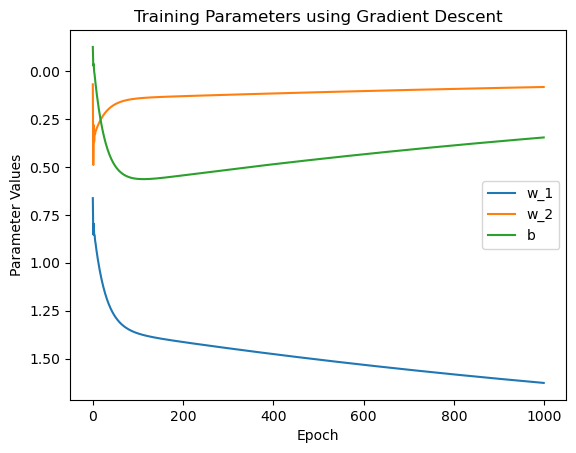

Prediction for x=4.0: 8.18881607055664


In [13]:
import torch
import matplotlib.pyplot as plt
x_data = [1.0,2.0,3.0]
y_data = [2.0,4.0,6.0]

w_1 = torch.tensor([1.0], requires_grad=True)
w_2 = torch.tensor([1.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

def forward(x):
    return w_1*x + w_2*x**2 + b

def loss(y,y_hat):
    return ((y_hat - y)**2)

w1_list = []
w2_list = []
b_list = []

for epoch in range(1000):
    print(f"Epoch :{epoch+1}")
    for x,y in zip(x_data, y_data):
        y_hat = forward(x)
        l = loss(y, y_hat)
        l.backward() # autograd will calculate the gradient for w_1, w_2 and b
        print(f"w_1 = {w_1.item()}, w_2 = {w_2.item()}, b = {b.item()}, loss = {l.item()}")
        w_1.data.sub_(0.01 * w_1.grad.data) # update
        w_2.data.sub_(0.01 * w_2.grad.data)
        b.data.sub_(0.01 * b.grad.data)
        w_1.grad.data.zero_() # clear the gradient for the next step
        w_2.grad.data.zero_()
        b.grad.data.zero_()
    w1_list.append(w_1.item())
    w2_list.append(w_2.item())
    b_list.append(b.item())

print(f"Final w_1: {w_1.item()}, w_2: {w_2.item()}, b: {b.item()}")

plt.plot(w1_list, label='w_1')
plt.plot(w2_list, label='w_2')
plt.plot(b_list, label='b')
plt.xlabel('Epoch')
plt.ylabel('Parameter Values')
plt.gca().invert_yaxis() # invert the y-axis to show the decrease of parameters over epochs
plt.title('Training Parameters using Gradient Descent')
plt.legend()
plt.show()

x_test = torch.tensor([4.0])
y_test = forward(x_test)
print(f"Prediction for x=4.0: {y_test.item()}")



**模型与数据不匹配**

使用二次模型去模拟线性模型，会导致收敛极慢，y^=w1\*x+w2*x^2+b,w1无线接近于2，w2与b无线接近与0。而w2为二次函数梯度极小->更新慢->收敛慢。调整学习率

# 使用pytorch实现线性模型

> 4个步骤
> 1. prepare dataset 准备数据集
> 2. Design model using class 设计模型
> 3. construct loss and optimizer 构造损失函数与优化器
> 4. Training cycle 训练

第一步在准备数据集时，需要考虑输入与输出的维度。y = wx + b,则需要根据x,y的维度，来设计权重w以及偏置量b的维度

In [ ]:
import torch

x_data = torch.tensor([[1.0],[2.0],[3.0]])
y_data = torch.tensor([[2.0],[4.0],[6.0]])

# define the model inherit from torch.nn.Module
class LinearModel(torch.nn.Module):
    # define prameters in the constructor,nn.Module will automatically register them as model parameters
    def __init__(self):
        super(LinearModel, self).__init__() # call the constructor of the parent class
        self.linear = torch.nn.Linear(1,1) # define a linear layer with 1 input and 1 output
    
    # nn.Module will automatically define the forward method as the forward pass of the model, we just need to implement it
    def forward(self,x):
        return self.linear(x) # define the forward pass of the model
    
model = LinearModel() # create an instance of the model

# use reduction parameter to specify how to reduce the loss over the batch, here we use mean to calculate the average loss
criterion = torch.nn.MSELoss() # define the loss function

optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # define the optimizer, here we use stochastic gradient descent, and pass the model parameters to it


for epoch in range(1000):
    y_pred = model(x_data) # make a prediction using the model, reshape x_data to be a column vector
    loss = criterion(y_pred, y_data) # calculate the loss 
    print(f"Epoch {epoch+1}: loss = {loss.item()}")
    optimizer.zero_grad() # clear the gradients for the next step
    loss.backward() # compute the gradients for the parameters
    optimizer.step() # update the parameters using the optimizer
print(f"Final parameters: {model.linear.weight.item()}, {model.linear.bias.item()}")

x_test = torch.tensor([4.0])
y_test = model(x_test.view(-1, 1))
print(f"Prediction for x=4.0: {y_test.item()}")

Epoch 1: loss = 25.616348266601562
Epoch 2: loss = 20.260873794555664
Epoch 3: loss = 16.02760124206543
Epoch 4: loss = 12.681363105773926
Epoch 5: loss = 10.03628158569336
Epoch 6: loss = 7.945428371429443
Epoch 7: loss = 6.292659759521484
Epoch 8: loss = 4.98617696762085
Epoch 9: loss = 3.9534130096435547
Epoch 10: loss = 3.1370105743408203
Epoch 11: loss = 2.4916305541992188
Epoch 12: loss = 1.9814342260360718
Epoch 13: loss = 1.5780943632125854
Epoch 14: loss = 1.259218454360962
Epoch 15: loss = 1.0071074962615967
Epoch 16: loss = 0.8077704906463623
Epoch 17: loss = 0.6501492857933044
Epoch 18: loss = 0.5255017876625061
Epoch 19: loss = 0.42691946029663086
Epoch 20: loss = 0.34893977642059326
Epoch 21: loss = 0.28724566102027893
Epoch 22: loss = 0.23842521011829376
Epoch 23: loss = 0.1997801810503006
Epoch 24: loss = 0.16917921602725983
Epoch 25: loss = 0.1449366956949234
Epoch 26: loss = 0.12572051584720612
Epoch 27: loss = 0.11047756671905518
Epoch 28: loss = 0.09837555885314941


> criterion 定义损失函数 该模型中使用了MSEloss系线性模型最常用的损失函数
>
> optimizer 定义优化器，即更新参数，让 loss 越来越小，让模型学得更快、更稳、更好。SGD随机梯度下降
>
> 常见的优化器有：
>
>        1. SGD 随机梯度下降
>
>        2. SGD + Momentum（带动量的 SGD）: 自带 “惯性”，会朝着正确方向加速解决 SGD 慢、震荡问题 
>
>        3. AdaGrad 学习率会自动调整 适合稀疏数据 缺点：越训练学习率越小，最后不动了
>
>        4. RMSprop 解决 AdaGrad 学习率衰减太快的问题 适合 RNN、时序数据
>
>        5. Adam（目前最常用、最强万能优化器）结合了 Momentum + RMSprop 自动调整学习率 训练快、稳定、  适用所有场景 90% 深度学习直接用 Adam！
>
>        6. AdamW（现在最主流）

使用Adagrad优化器

In [8]:
import torch

x_data = torch.tensor([[1.0],[2.0],[3.0]])
y_data = torch.tensor([[2.0],[4.0],[6.0]])

# define the model inherit from torch.nn.Module
class LinearModel(torch.nn.Module):
    # define prameters in the constructor,nn.Module will automatically register them as model parameters
    def __init__(self):
        super(LinearModel, self).__init__() # call the constructor of the parent class
        self.linear = torch.nn.Linear(1,1) # define a linear layer with 1 input and 1 output
    
    # nn.Module will automatically define the forward method as the forward pass of the model, we just need to implement it
    def forward(self,x):
        return self.linear(x) # define the forward pass of the model
    
model = LinearModel() # create an instance of the model

# use reduction parameter to specify how to reduce the loss over the batch, here we use mean to calculate the average loss
criterion = torch.nn.MSELoss() # define the loss function

# use Adagrad optimizer which adapts the learning rate for each parameter based on the historical gradients, it can be more effective for sparse data or when the optimal learning rate is not known
optimizer = torch.optim.Adagrad(model.parameters(), lr=1.0) # define the optimizer, here we use stochastic gradient descent, and pass the model parameters to it


for epoch in range(1000):
    y_pred = model(x_data) # make a prediction using the model, reshape x_data to be a column vector
    loss = criterion(y_pred, y_data) # calculate the loss 
    print(f"Epoch {epoch+1}: loss = {loss.item()}")
    optimizer.zero_grad() # clear the gradients for the next step
    loss.backward() # compute the gradients for the parameters
    optimizer.step() # update the parameters using the optimizer
print(f"Final parameters: {model.linear.weight.item()}, {model.linear.bias.item()}")

x_test = torch.tensor([4.0])
y_test = model(x_test.view(-1, 1))
print(f"Prediction for x=4.0: {y_test.item()}")

Epoch 1: loss = 25.9721622467041
Epoch 2: loss = 4.087503910064697
Epoch 3: loss = 0.9323436617851257
Epoch 4: loss = 0.35082772374153137
Epoch 5: loss = 0.2343319207429886
Epoch 6: loss = 0.20581193268299103
Epoch 7: loss = 0.19426755607128143
Epoch 8: loss = 0.18619108200073242
Epoch 9: loss = 0.1789991706609726
Epoch 10: loss = 0.17219102382659912
Epoch 11: loss = 0.16566316783428192
Epoch 12: loss = 0.159387469291687
Epoch 13: loss = 0.15335118770599365
Epoch 14: loss = 0.14754442870616913
Epoch 15: loss = 0.14195841550827026
Epoch 16: loss = 0.13658447563648224
Epoch 17: loss = 0.13141469657421112
Epoch 18: loss = 0.12644116580486298
Epoch 19: loss = 0.12165644019842148
Epoch 20: loss = 0.11705324053764343
Epoch 21: loss = 0.11262480169534683
Epoch 22: loss = 0.1083642765879631
Epoch 23: loss = 0.10426530987024307
Epoch 24: loss = 0.10032188892364502
Epoch 25: loss = 0.09652795642614365
Epoch 26: loss = 0.09287768602371216
Epoch 27: loss = 0.08936575055122375
Epoch 28: loss = 0.08

Adagrad 的**学习率会不断变小**，而且变小得太快了！

Adagrad 公式：
$$
lr_{有效} = \frac{初始lr}{\sqrt{历史梯度平方和}}
$$

1. 梯度平方会一直累加，越来越大
2. 有效学习率越训练越小
3. 到最后参数几乎不更新，直接卡在半路不收敛！

设置的 lr=0.01，分子较小，且分母不断增大，导致收敛极慢

**一句话记住 Adagrad 的坑**：Adagrad 天生学习率衰减快，必须用大的初始学习率（通常 1.0 左右）！

---

使用Adam优化器

In [10]:
import torch

x_data = torch.tensor([[1.0],[2.0],[3.0]])
y_data = torch.tensor([[2.0],[4.0],[6.0]])

# define the model inherit from torch.nn.Module
class LinearModel(torch.nn.Module):
    # define prameters in the constructor,nn.Module will automatically register them as model parameters
    def __init__(self):
        super(LinearModel, self).__init__() # call the constructor of the parent class
        self.linear = torch.nn.Linear(1,1) # define a linear layer with 1 input and 1 output
    
    # nn.Module will automatically define the forward method as the forward pass of the model, we just need to implement it
    def forward(self,x):
        return self.linear(x) # define the forward pass of the model
    
model = LinearModel() # create an instance of the model

# use reduction parameter to specify how to reduce the loss over the batch, here we use mean to calculate the average loss
criterion = torch.nn.MSELoss() # define the loss function

# use Adagrad optimizer which adapts the learning rate for each parameter based on the historical gradients, it can be more effective for sparse data or when the optimal learning rate is not known
optimizer = torch.optim.Adam(model.parameters(), lr=1.0) # define the optimizer, here we use stochastic gradient descent, and pass the model parameters to it


for epoch in range(100):
    y_pred = model(x_data) # make a prediction using the model, reshape x_data to be a column vector
    loss = criterion(y_pred, y_data) # calculate the loss 
    print(f"Epoch {epoch+1}: loss = {loss.item()}")
    optimizer.zero_grad() # clear the gradients for the next step
    loss.backward() # compute the gradients for the parameters
    optimizer.step() # update the parameters using the optimizer
print(f"Final parameters: {model.linear.weight.item()}, {model.linear.bias.item()}")

x_test = torch.tensor([4.0])
y_test = model(x_test.view(-1, 1))
print(f"Prediction for x=4.0: {y_test.item()}")

Epoch 1: loss = 28.456457138061523
Epoch 2: loss = 5.162431240081787
Epoch 3: loss = 0.7378073334693909
Epoch 4: loss = 6.907467365264893
Epoch 5: loss = 11.101370811462402
Epoch 6: loss = 9.549145698547363
Epoch 7: loss = 5.170522212982178
Epoch 8: loss = 1.4323874711990356
Epoch 9: loss = 0.25614240765571594
Epoch 10: loss = 1.5428433418273926
Epoch 11: loss = 3.640354871749878
Epoch 12: loss = 4.7600531578063965
Epoch 13: loss = 4.237762928009033
Epoch 14: loss = 2.618030548095703
Epoch 15: loss = 0.9664828181266785
Epoch 16: loss = 0.1493941992521286
Epoch 17: loss = 0.39765027165412903
Epoch 18: loss = 1.270209789276123
Epoch 19: loss = 2.022702217102051
Epoch 20: loss = 2.130046844482422
Epoch 21: loss = 1.5750032663345337
Epoch 22: loss = 0.7542230486869812
Epoch 23: loss = 0.15952159464359283
Epoch 24: loss = 0.06753595918416977
Epoch 25: loss = 0.40247488021850586
Epoch 26: loss = 0.8327446579933167
Epoch 27: loss = 1.0229583978652954
Epoch 28: loss = 0.8542463779449463
Epoch 

**Adam = 动量（惯性） + RMSprop（自适应学习率）**
它同时解决了两个问题：
1. SGD 慢、震荡 → 加动量，像小球滚下山，直冲谷底
2. Adagrad 学习率衰减太快 → 用滑动平均，只保留近期梯度，不会越来越小

优点: 1.收敛速度极快 2.自适应学习率 3.自带动量
缺点: 泛化能力略差与SDG

算法思想: 
    本质是动量法 + RMSprop的结合体，同时引入偏差修正，利用梯度的一阶矩估计（动量）和二阶矩估计（自适应学习率）动态调整每个参数的学习率，在保证收敛速度的同时稳定训练过程。
1. 一阶矩（动量思想）对梯度做指数滑动平均，保留历史梯度方向，消除 SGD 的震荡，让参数更新更顺滑，类似小球滚下山的惯性，直冲局部最优。
2. 二阶矩（RMSprop 思想）对梯度平方做指数滑动平均，自适应缩放学习率：梯度大时学习率自动减小，梯度小时学习率自动放大，避免 Adagrad 因累积所有历史梯度导致学习率过早衰减至 0。

偏差修正训练初期一阶、二阶矩初始值接近 0，会产生偏差，通过修正因子抵消初始偏差，让前期更新更稳定。
学习率α，一阶矩衰减系数β1​（默认 0.9），二阶矩衰减系数β2​（默认 0.999），平滑项ϵ（默认10−8）

---

# 逻辑斯蒂回归

逻辑斯蒂回归 = 线性回归 + sigmoid 函数，用来做二分类任务。实际是分类模型。
将线性模型的结果使用sigmoid压缩至(0,1)的概率空间，来完成分类任务。

损失函数(交叉熵)：
$$
    loss = - (ylog{y^{1}}+(1-y)log{(1-y^{1})})
$$
当y = 0 时，$loss = -log{(1-y^{1})}$ y^​ 越接近 0 → loss 越接近 0, y^​ 越接近 1 → loss 趋向无穷大

当y = 1 时，$loss = -log{y^{1}}$ y^​ 越接近 1 → loss 越接近 0 ，y^​ 越接近 0 → loss 趋向无穷大

In [ ]:
import torch

x_data = torch.tensor([[1.0],[2.0],[3.0]])
y_data = torch.tensor([[0.0],[0.0],[1.0]])

class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1,1) # define a linear layer with 1 input and 1 output
    
    def forward(self,x):
        # use sigmoid func to get the output between 0 and 1, 
        return torch.sigmoid(self.linear(x))

model = LogisticRegressionModel() # create an instance of the model

criterion = torch.nn.BCELoss() # define the loss function for binary classification, it combines a sigmoid layer and the binary cross-entropy loss in one single class

optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # define the optimizer, here we use stochastic gradient descent, and pass the model parameters to it

for epoch in range(1000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data) # calculate the loss
    print(f"Epoch {epoch+1}: loss = {loss.item()}")
    optimizer.zero_grad() # clear the gradients for the next step
    loss.backward() # compute the gradients for the parameters
    optimizer.step() # update the parameters using the optimizer

x_test = torch.tensor([4.0])
y_test = model(x_test.view(-1, 1))
print(f"Prediction for x=4.0: {y_test.item()}")

Epoch 1: loss = 0.5905587673187256
Epoch 2: loss = 0.5883331298828125
Epoch 3: loss = 0.5863525867462158
Epoch 4: loss = 0.5846138596534729
Epoch 5: loss = 0.5830993056297302
Epoch 6: loss = 0.581768810749054
Epoch 7: loss = 0.580558717250824
Epoch 8: loss = 0.5793954730033875
Epoch 9: loss = 0.5782198309898376
Epoch 10: loss = 0.5769992470741272
Epoch 11: loss = 0.5757248997688293
Epoch 12: loss = 0.5744012594223022
Epoch 13: loss = 0.573038637638092
Epoch 14: loss = 0.571648895740509
Epoch 15: loss = 0.5702431797981262
Epoch 16: loss = 0.5688310265541077
Epoch 17: loss = 0.5674205422401428
Epoch 18: loss = 0.5660175681114197
Epoch 19: loss = 0.5646263957023621
Epoch 20: loss = 0.5632491707801819
Epoch 21: loss = 0.5618867874145508
Epoch 22: loss = 0.5605385303497314
Epoch 23: loss = 0.5592024922370911
Epoch 24: loss = 0.5578762888908386
Epoch 25: loss = 0.5565569996833801
Epoch 26: loss = 0.5552420616149902
Epoch 27: loss = 0.5539291501045227
Epoch 28: loss = 0.5526167750358582
Epoch

<!--
 * @Author: YhL YhL00004_17@163.com
 * @Date: 2026-04-12 22:41:40
 * @LastEditors: YhL YhL00004_17@163.com
 * @LastEditTime: 2026-04-17 21:45:01
 * @FilePath: \py\dl\liner\demo1.ipynb
 * @Description: 这是默认设置,请设置`customMade`, 打开koroFileHeader查看配置 进行设置: https://github.com/OBKoro1/koro1FileHeader/wiki/%E9%85%8D%E7%BD%AE
-->
# 多维度输入
二维数据，一般行称为样本，列称为特征，做矩阵运算
$$
\left[\begin{matrix}
    z^{1} \\
    . \\
    . \\
    z^{N} \\
\end{matrix}\right]
 = 
\left[\begin{matrix}
    x_{1}^{1} ... x_{8}^{1} \\
    .         ... . \\
    .         ... . \\
    x_{1}^{N} ... x_{8}^{N}\\
\end{matrix}\right]
\left[\begin{matrix}
    w_{1} \\
    . \\
    . \\
    w_{8} \\
\end{matrix}\right]
+ 
\left[\begin{matrix}
    b \\
    . \\
    . \\
    b \\
\end{matrix}\right]
$$

Epoch 1: loss = 2.8508965969085693
Epoch 2: loss = 2.2445905208587646
Epoch 3: loss = 1.719985842704773
Epoch 4: loss = 1.2651911973953247
Epoch 5: loss = 0.924682080745697
Epoch 6: loss = 0.8660385012626648
Epoch 7: loss = 0.9121577739715576
Epoch 8: loss = 0.933862030506134
Epoch 9: loss = 0.9311960339546204
Epoch 10: loss = 0.903245747089386
Epoch 11: loss = 0.8573946952819824
Epoch 12: loss = 0.8085094094276428
Epoch 13: loss = 0.7671177983283997
Epoch 14: loss = 0.7359700798988342
Epoch 15: loss = 0.71369868516922
Epoch 16: loss = 0.6981133818626404
Epoch 17: loss = 0.6867708563804626
Epoch 18: loss = 0.6781866550445557
Epoch 19: loss = 0.6717868447303772
Epoch 20: loss = 0.6672231554985046
Epoch 21: loss = 0.6639577150344849
Epoch 22: loss = 0.6610052585601807
Epoch 23: loss = 0.6578338146209717
Epoch 24: loss = 0.6546507477760315
Epoch 25: loss = 0.6519730687141418
Epoch 26: loss = 0.6496698260307312
Epoch 27: loss = 0.6474462151527405
Epoch 28: loss = 0.6451864838600159
Epoch 2

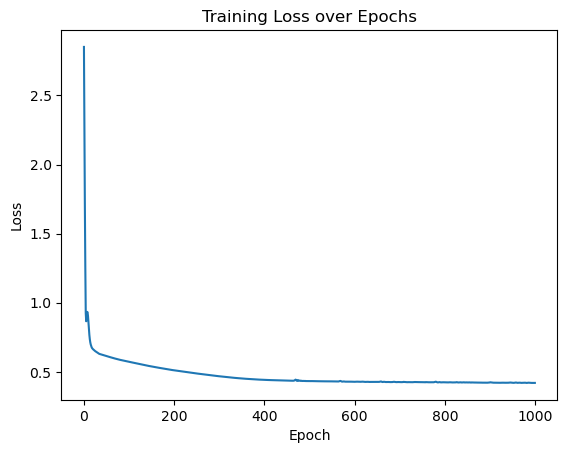

In [22]:
import torch
import numpy as np
# prepare data
import os
import matplotlib.pyplot as plt
os.chdir("D:/workspace/py/dl/liner")
xy = np.loadtxt('../data/diabetes.csv', delimiter=',', dtype=np.float32)
x_data = torch.from_numpy(xy[:,:-1]) # all rows, all columns except the last one
y_data = torch.from_numpy(xy[:,[-1]]) # all rows, only the last column

class model(torch.nn.Module):
    def __init__(self):
        super(model, self).__init__()
        self.linear1 = torch.nn.Linear(8,6) # 8 input features and 6 output
        self.linear2 = torch.nn.Linear(6,4) # 6 input features and 4 output
        self.linear3 = torch.nn.Linear(4,1) # 4 input features and 1 output
    
    def forward(self,x):
        # can use different activation func for different layers,but last layer should use sigmoid
        x = torch.relu(self.linear1(x)) # use ReLU activation function for the hidden layer
        x = torch.relu(self.linear2(x))
        x = torch.sigmoid(self.linear3(x)) # use sigmoid activation function for the output layer to get the output between 0 and 1
        return x

model = model() # create an instance of the model

criterion = torch.nn.BCELoss() # define the loss function for binary classification, it combines a sigmoid layer and the binary cross-entropy loss in one single class

optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # define the optimizer, here we use stochastic gradient descent, and pass the model parameters to it

loss_list1 = []

for epoch in range(1000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data) # calculate the loss
    loss_list1.append(loss.item())
    print(f"Epoch {epoch+1}: loss = {loss.item()}")
    optimizer.zero_grad() # clear the gradients for the next step
    loss.backward() # compute the gradients for the parameters
    optimizer.step() # update the parameters using the optimizer

plt.plot(loss_list1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()

## 常用的激活函数以及优缺点
1. sigmoid
$$
\sigma(\frac{1}{1+e^{-x}})
$$
输出: 0 ~ 1

用途：做二分类输出概率

缺点：易梯度消失(输入很大或很小时)、非 0 均值

2. Tanh(双曲正弦)
$$
tanh(x) = \frac{e^{x}-e^{-x}}{e^{x}+e^{-x}}
$$
<p align="center">
  <img src="../img/tanh.png" alt="tanh" width="400">
</p>
输出: -1 ~ 1

用途：早期 RNN、小网络隐藏层，0 均值，比 Sigmoid 收敛快

缺点：仍会梯度消失

3. ReLU（最常用！）
$$
ReLU(x)=max(0,x)
$$
<p align="center">
  <img src="../img/relu.png" alt="relu" width="400">
</p>
输出：0 ~ +∞ ,正数取值不变，负数取0

优点：
计算极快
正区间梯度为 1，缓解梯度消失
用途：CNN、Transformer、MLP 隐藏层几乎都用它
缺点：负数部分直接死区（梯度为 0），有些神经元会永久死亡（输入一直负，梯度永远 0）

4. Softmax
$$
\sigma(z)_{i} = \frac{e^{z_{i}}}{\sum{e^{z_{j}}}}
$$
<p align="center">
  <img src="../img/sigmoid.png" alt="sigmoid" width="400">
</p>
​​输出：和为 1 的概率分布

用途：多分类输出层

5. GELU（现在大模型标配）
$$
xΦ(x)
$$
平滑、带随机正则性质

用途：BERT、GPT、LLaMA 等所有现代大模型都用 GELU

---

# Dataset and DataLoader
人工组织数据有什么缺点？
1. 顺序输入，缺少泛化能力
2. 数据较大无法一次读入
3. 单进程读入较慢

Epoch：所有数据的训练次数，Batch-Size：一次迭代中的数据大小，Iterations：epochs/batch-size。迭代轮数

**优点：**

1. DataLoader 自动将 Dataset 中的数据分成指定大小的 batch，并提供一个 Python 迭代器，可以用 for batch in dataloader: 轻松遍历。

2. DataLoader(shuffle=True) 会在每个 epoch 开始时自动打乱样本顺序，无需手动实现。

3. DataLoader(num_workers=N) 可以用多个子进程并行加载数据，边训练边预取下一批，显著提升 GPU 利用率。

4. Dataset 可以定义每次只读取一个样本（如从磁盘读取图片），DataLoader 按需加载，内存占用仅为一个 batch 的大小。

5. 继承 Dataset（抽象类需继承） 类并实现 __len__ 和 __getitem__，将原始数据读取、变换（如归一化、随机裁剪、翻转）封装在一起。DataLoader 统一调用，保证代码可读性和可复用性。

Epoch 1, Average Loss: 0.6567
Epoch 2, Average Loss: 0.6545
Epoch 3, Average Loss: 0.6516
Epoch 4, Average Loss: 0.6497
Epoch 5, Average Loss: 0.6456
Epoch 6, Average Loss: 0.6420
Epoch 7, Average Loss: 0.6393
Epoch 8, Average Loss: 0.6347
Epoch 9, Average Loss: 0.6306
Epoch 10, Average Loss: 0.6259
Epoch 11, Average Loss: 0.6229
Epoch 12, Average Loss: 0.6169
Epoch 13, Average Loss: 0.6150
Epoch 14, Average Loss: 0.6092
Epoch 15, Average Loss: 0.6040
Epoch 16, Average Loss: 0.6016
Epoch 17, Average Loss: 0.5960
Epoch 18, Average Loss: 0.5915
Epoch 19, Average Loss: 0.5856
Epoch 20, Average Loss: 0.5815
Epoch 21, Average Loss: 0.5756
Epoch 22, Average Loss: 0.5725
Epoch 23, Average Loss: 0.5680
Epoch 24, Average Loss: 0.5645
Epoch 25, Average Loss: 0.5614
Epoch 26, Average Loss: 0.5563
Epoch 27, Average Loss: 0.5569
Epoch 28, Average Loss: 0.5529
Epoch 29, Average Loss: 0.5494
Epoch 30, Average Loss: 0.5492
Epoch 31, Average Loss: 0.5461
Epoch 32, Average Loss: 0.5440
Epoch 33, Average

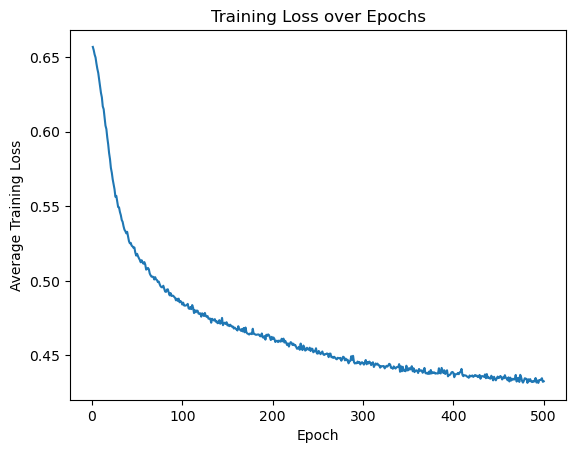


✅ 模型测试正确率: 78.26%


In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt
os.chdir("D:/workspace/py/dl/liner")

class DiabetesDataset(Dataset):

    def __init__(self,file_path):
        xy = np.loadtxt(file_path,delimiter=',', dtype=np.float32)
        self.len = xy.shape[0] # number of samples
        self.x = torch.from_numpy(xy[:, :-1])
        self.y = torch.from_numpy(xy[:, [-1]])

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class DiabetesModel(torch.nn.Module):
    def __init__(self):
        super(DiabetesModel, self).__init__()
        self.linear1 = torch.nn.Linear(8,6) # 8 input features and 6 output
        self.linear2 = torch.nn.Linear(6,4) # 6 input features and 4 output
        self.linear3 = torch.nn.Linear(4,1) # 4 input features and 1 output
        self.sigmoid = torch.nn.Sigmoid() # define sigmoid activation function for the output layer

    def forward(self, x):
        x = torch.relu(self.linear1(x)) # use ReLU activation function for the hidden layer
        x = torch.relu(self.linear2(x))
        x = self.sigmoid(self.linear3(x)) # use sigmoid activation function for the output layer to get the output between 0 and 1
        return x


dataset = DiabetesDataset("../data/diabetes.csv.gz")
# create a dataLoader to load the data by batch,shuffle,and multiprocessing 2
train_loader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)

model = DiabetesModel() # create an instance of the model

criterion = torch.nn.BCELoss(reduction='mean') # define the loss function for binary classification, it combines a sigmoid layer and the binary cross-entropy loss in one single class

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # define the optimizer, here we use stochastic gradient descent, and pass the model parameters to it

loss_list = []
epochs = []

if __name__ == "__main__":
    for epoch in range(500):
        running_loss = 0.0
        batch_count = 0
        
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            y_pred = model(inputs)
            loss = criterion(y_pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            batch_count += 1

        # 计算每个 epoch 的平均 loss
        avg_loss = running_loss / batch_count
        loss_list.append(avg_loss)
        epochs.append(epoch + 1)

        print(f"Epoch {epoch+1}, Average Loss: {avg_loss:.4f}")

plt.plot(epochs, loss_list)
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.title('Training Loss over Epochs')
plt.show()


test_dataset = DiabetesDataset("../data/diabetes.csv.gz") # create a dataset for testing, can use the same file as training since we just want to demonstrate how to use DataLoader
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False) # create a dataLoader for testing, no need to shuffle
correct = 0
total = 0

with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        outputs = model(inputs)  

        predicted = (outputs > 0.5).float()

        total += labels.size(0) 
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n✅ 模型测试正确率: {accuracy:.2f}%")




# 加载minst数据集并训练

Epoch 1/5, Train Loss: 0.1976
Epoch 2/5, Train Loss: 0.0906
Epoch 3/5, Train Loss: 0.0671
Epoch 4/5, Train Loss: 0.0537
Epoch 5/5, Train Loss: 0.0410

✅ Test Accuracy: 97.61%


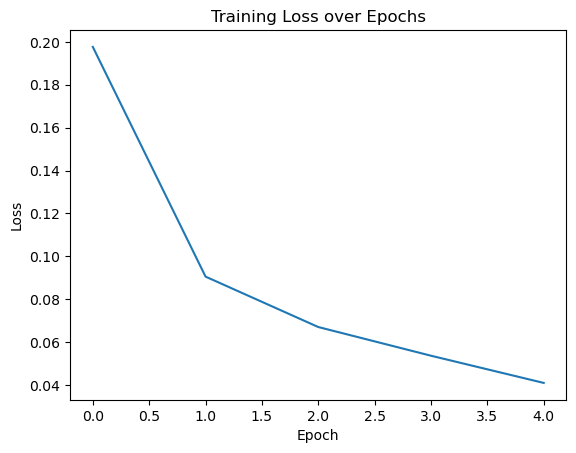

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
batch_size = 32
lr = 0.001
epochs = 5

transform = transforms.Compose([
    transforms.ToTensor(),                # pil or numpy arr transform to tensor,range 0~1 z-
    transforms.Normalize((0.1307,), (0.3081,)) # standardize the data with mean and std of MNIST dataset
])
# load MNIST dataset (will automatically download if not exist, if already exist it will just use it)
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# testsets usually don't need to shuffle, because we just want to evaluate the model on the test set, and the order of the samples doesn't matter
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64) # 10 output classes for MNIST digits 0-9
        self.fc5 = nn.Linear(64, 10) # 10 output classes for MNIST digits 0-9

    def forward(self, x):
        x = x.view(-1, 28*28)  # [batch, 1, 28, 28] → [batch, 784]
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)        # last layer without activation, because CrossEntropyLoss will apply softmax internally
        return x

model = MNISTModel()
criterion = nn.CrossEntropyLoss()  # multi-class classification loss function
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

loss_list = []
if __name__ == "__main__":
    for epoch in range(epochs):
        model.train() # set the model to training mode, which is important for layers like dropout and batchnorm
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")

    # test + calculate accuracy
    model.eval() # set the model to evaluation mode, which is important for layers like dropout and batchnorm
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"\n✅ Test Accuracy: {100 * correct / total:.2f}%")
    plt.plot(loss_list)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.show()

# titanic生存预测
> 首先是一个二分类问题，预测概率 survival 0 = No, 1 = Yes

机器学习 or 深度学习拿到数据后的完成训练的基本操作流程
1. 加载数据集:标签 y 是什么，特征 X 是什么
2. 数据探索EDA：看缺失值、异常值、标签分布是否均衡、哪些对模型有用，哪些没用
3. 数据预处理：缺失值？异常值？特征转换（字符串->编码，文本->词向量，token）？归一化标准化
4. 特征工程：构造新的特征，去掉无用
5. 数据集划分
6. 构建模型
7. 模型训练
8. 模型评估
9. 模型优化

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import os
os.chdir("D:/workspace/py/dl/liner")

# handle missing values, we can fill them with some reasonable values, such as the median for numerical features and the mode for categorical features
def handle_missing_values(df):
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    return df

# drop unvalue col,such as PassengerId, Name, Ticket, etc. because they are not useful for prediction
def delete_unnecessary_columns(df):
    # drop the columns that are not useful for prediction, such as PassengerId, Name, Ticket, etc.
    df.drop(['PassengerId', 'Name', 'Ticket','Cabin'], axis=1, inplace=True)
    return df

# encode categorical
def encode_str(df):
    # Sex：male=0, female=1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    
    # Embarked：S=0, C=1, Q=2
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    return df

def add_features(df):
    # add new features, such as FamilySize, which is the sum of SibSp and Parch plus 1 (for the passenger themselves)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['isAlone'] = (df['FamilySize'] == 1).astype(int) # add a new feature isAlone, which is 1 if the passenger is alone (FamilySize == 1) and 0 otherwise
    return df

# normalize numerical features, such as Age and Fare, to have mean 0 and std 1, which can help the model converge faster
def normalize_features(df):
    # for all numerical features, we can normalize them to have mean 0 and std 1, which can help the model converge faster
    for col in ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']:
        df[col] = (df[col] - df[col].mean()) / (df[col].std() + 1e-8)
    return df


def read_data(df):
    x_data = df.drop('Survived', axis=1).values # drop the target column and get the feature values as a numpy array
    y_data = df['Survived'].values # get the target values as a numpy array
    return x_data, y_data

def read_test_data(df):
    x_data = df.values # get the feature values as a numpy array
    return x_data

# process the data, including handling missing values, deleting unnecessary columns, encoding categorical features, adding new features, normalizing numerical features, and reading the data into x_data and y_data
def process_data(file_path, flag):
    df = pd.read_csv(file_path)
    df = handle_missing_values(df)
    df = delete_unnecessary_columns(df)
    df = encode_str(df)
    df = add_features(df)
    df = normalize_features(df)

    if flag == "train":
        x_data, y_data = read_data(df)
        return x_data, y_data
    else:
        x_data = read_test_data(df)
        return x_data, None

class TianicDataset(torch.utils.data.Dataset):
    def __init__(self, file_path, flag):
        self.flag = flag
        self.x_data, self.y_data = process_data(file_path, flag)
        self.x_data = torch.tensor(self.x_data, dtype=torch.float32)
        
        if self.flag == "train":
            self.y_data = torch.tensor(self.y_data, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        if self.flag == "train":
            return self.x_data[idx], self.y_data[idx]
        else:
            return self.x_data[idx]
    
# train dataloader
train_dataset = TianicDataset("../data/titanic/train.csv", flag="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# test 
test_dataset = TianicDataset("../data/titanic/test.csv", flag="test")
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


class TitanicModel(nn.Module):
    def __init__(self):
        super(TitanicModel, self).__init__()
        self.fc1 = nn.Linear(9, 16) # 8 input features and 16 output
        self.fc2 = nn.Linear(16, 8) # 16 input features and 8 output
        self.fc3 = nn.Linear(8, 1) # 8 input features and 1 output
    
    def forward(self, x):
        x = torch.relu(self.fc1(x)) # use ReLU activation function for the hidden layer
        x = torch.relu(self.fc2(x))
        x = self.fc3(x) # use sigmoid activation function for the output layer to get the output between 0 and 1
        return x


model = TitanicModel() # create an instance of the model
criterion = nn.BCEWithLogitsLoss() # binary classification loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # define the optimizer,

# train the model
def train(epochs):
    loss_list = []
    for epoch in range(epochs):
        model.train() # set the model to training mode
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")
    return loss_list

def test():
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs in test_loader:
            outputs = model(inputs)
            pred = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()
            predictions.extend(pred.flatten())
    
    df_test = pd.read_csv("../data/titanic/test.csv")
    submission = pd.DataFrame({
        "PassengerId": df_test["PassengerId"],
        "Survived": predictions
    })
    submission.to_csv("titanic_submission.csv", index=False)
    print("\n✅ 预测完成！结果已保存至 titanic_submission.csv")

def calculate_accuracy():
    answer = pd.read_csv('../data/titanic/gender_submission.csv')
    predicted_test = pd.read_csv("titanic_submission.csv")
    merged = pd.merge(answer, predicted_test, on='PassengerId')
    correct = (merged['Survived_x'] == merged['Survived_y']).sum()
    total = len(merged)
    accuracy = 100 * correct / total
    print(f"\n✅ 模型测试正确率: {accuracy:.2f}%")

if __name__ == "__main__":
    calculate_accuracy()


✅ 模型测试正确率: 92.58%


# 多分类问题
Otto Group Product Classification Challenge共10个类的分类问题，93个特征

Epoch 1/20, Train Loss: 0.7881
Epoch 2/20, Train Loss: 0.6032
Epoch 3/20, Train Loss: 0.5652
Epoch 4/20, Train Loss: 0.5389
Epoch 5/20, Train Loss: 0.5182
Epoch 6/20, Train Loss: 0.5025
Epoch 7/20, Train Loss: 0.4882
Epoch 8/20, Train Loss: 0.4756
Epoch 9/20, Train Loss: 0.4642
Epoch 10/20, Train Loss: 0.4545
Epoch 11/20, Train Loss: 0.4467
Epoch 12/20, Train Loss: 0.4370
Epoch 13/20, Train Loss: 0.4303
Epoch 14/20, Train Loss: 0.4226
Epoch 15/20, Train Loss: 0.4173
Epoch 16/20, Train Loss: 0.4100
Epoch 17/20, Train Loss: 0.4047
Epoch 18/20, Train Loss: 0.4001
Epoch 19/20, Train Loss: 0.3918
Epoch 20/20, Train Loss: 0.3878

✅ 提交文件已生成：otto_submission.csv


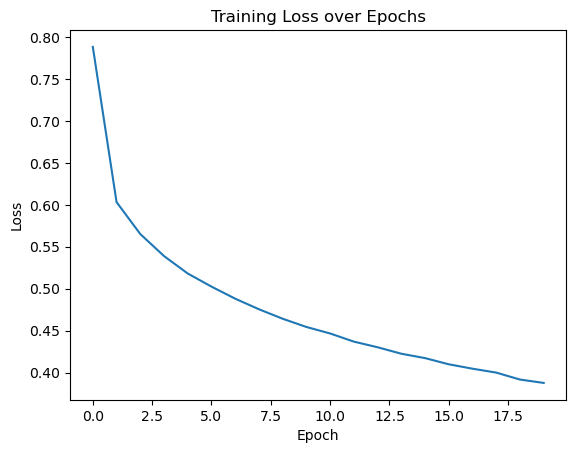

In [12]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
os.chdir("D:/workspace/py/dl/liner")

def prepare_data(file_path, flag="train"):
    df = pd.read_csv(file_path)
    if flag == "train":
        df['target'] = df['target'].str.split('_').str[1].astype(int) - 1
    return df

class OttoDataset(torch.utils.data.Dataset):
    def __init__(self, file_path, flag="train"):
        self.df = prepare_data(file_path, flag=flag)
        self.flag = flag
        if flag == "train":
            self.x_data = torch.tensor(self.df.drop(['id', 'target', 'target'], axis=1).values, dtype=torch.float32)
            self.y_data = torch.tensor(self.df['target'].values, dtype=torch.long) # for multi-class classification, the target should be long type
        else:
            self.x_data = torch.tensor(self.df.drop(['id'], axis=1).values, dtype=torch.float32)

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        if self.flag == "train":
            return self.x_data[idx], self.y_data[idx]
        else:
            return self.x_data[idx]

# train
train_dataset = OttoDataset("../data/otto-group-product-classification-challenge/train.csv")
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


# test
test_dataset = OttoDataset("../data/otto-group-product-classification-challenge/test.csv", flag="test")
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class OttoModel(torch.nn.Module):
    def __init__(self):
        super(OttoModel, self).__init__()
        self.fc1 = torch.nn.Linear(93, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 32)
        self.fc4 = torch.nn.Linear(32, 9) # 9 output classes for Otto dataset

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x) # last layer without activation, because CrossEntropyLoss will apply softmax internally
        return x
    
model = OttoModel()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

def train(epochs):
    loss_list = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")
    return loss_list

def test():
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs in test_loader:
            outputs = model(inputs)
            prob = torch.softmax(outputs, dim=1)
            predictions.append(prob.cpu().numpy())
    
    predictions = np.concatenate(predictions, axis=0)
    df_test = pd.read_csv("../data/otto-group-product-classification-challenge/test.csv")
    submission = pd.DataFrame({
        "id": df_test["id"],
        "Class_1": predictions[:, 0],
        "Class_2": predictions[:, 1],
        "Class_3": predictions[:, 2],
        "Class_4": predictions[:, 3],
        "Class_5": predictions[:, 4],
        "Class_6": predictions[:, 5],
        "Class_7": predictions[:, 6],
        "Class_8": predictions[:, 7],
        "Class_9": predictions[:, 8],
    })
    submission.to_csv("otto_submission.csv", index=False)
    print("\n✅ 提交文件已生成：otto_submission.csv")

if __name__ == "__main__":
    loss_list = train(20)
    test()
    plt.plot(loss_list)  
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.show()

---

# 如何评价模型以及训练结果
最基本的有几个参数，训练loss是否在下降？测试loss是否也下降？若训练很好，测试很高，说明模型出现过拟合。

对应任务的评价指标
1. 任务分类：accuracy，auc，roc，Confusion Matrix 混淆矩阵
2. 回归任务：MAE，MSE
3. 时序预测：长期预测是否飘移严重

泛化能力：模型在没见过的数据上表现好不好，三层验证，train，val验证集，test测试集

# 模型训练优化方式
在四个阶段分别可以优化，数据阶段、构建模型、构造损失和优化器、训练周期和测试
1. 数据阶段：分析数据对训练哪些权重较大，以及将某些特征归一化、标准化、加特征、编码、去噪声、某些数据分布范围较大稀疏，影响梯度。
2. 模型优化：加深/加宽模型（引入hidden层），换更强的模型，加正则防止过拟合（dropout，LayerNorm / BatchNorm，L1、L2 权重衰减（weight_decay））
3. 训练优化：学习率调整，优化器，调整batch_size,梯度裁剪防止梯度爆炸

---

# CNN
普通全连接网络：1. 把图片拉成一长串数字，会丢失空间信息  2. 参数极多，容易过拟合、训练慢

CNN 靠三个关键结构解决问题：
1. 卷积层（Convolution）用小卷积核在图片上滑动，提取特征：边缘→纹理→形状→整体物体。
2. 池化层（Pooling）对特征图降采样，减少计算量，同时让模型对位置、大小变化不敏感。
3. 全连接层最后把提取好的特征映射成分类结果。

例如：输入图像为(C,W,H)，C表示channel图层,RGB中就有3层图层，W，H表示图像的高宽。

**卷积原理**：用一个小卷积核（Filter/Kernel）在图像上从左到右、从上到下滑动，每滑到一个位置，就做对应位置相乘再求和，得到一个新值。
对于每个channel使用的卷积核可以不同，但最后所有channel卷积后的结果，叠加为一个channel

输入：$X∈R^{H×W×C}$             卷积核：$W∈R^{k×k×C}$               $out=\sum(X_{c}∗W_c)$

注意几个参数：
1. padding：填充，可以控制卷积结果的W，H,防止图片越卷越小，最后缩没了,保留边缘信息
2. stride：卷积核移动步长,快速降维、压缩特征（类似池化的作用）

多通道卷积 → 逐通道分别算 → 全部相加 → 输出 1 个通道。如果你想要输出 K 个通道，只需要：准备 K 组 这样的卷积核

**池化层**：
在一个小窗口内做统计，不学习参数，只做降维、压缩信息、增强鲁棒性。

常见两种：
1. 最大池化 Max Pooling：取窗口内最大值
2. 平均池化 Avg Pooling：取窗口内平均值

In [2]:
# convolutional layer
import torch
in_channels = 3
out_channels = 10
kernel_size = 3
width,hight = 100,100
batch_size = 1
# use 10*3*3*3 convolutional kernels to extract features from the input image, which has 3 channels (e.g., RGB) and size 100*100, and produce an output feature map with 10 channels and size 98*98 (because of the kernel size of 3 and no padding)
input = torch.randn(batch_size, in_channels, width, hight) # create a random input tensor with shape [batch_size, in_channels, width, height]

conv_layer = torch.nn.Conv2d(in_channels, out_channels, kernel_size)

output = conv_layer(input) # apply the convolutional layer to the input tensor
print(f"Output shape: {output.shape}") # print the shape of the output tensor,
print(f"weights shape: {conv_layer.weight.shape}") # print the shape of the convolutional kernels, which should be [out_channels, in_channels, kernel_size, kernel_size]

Output shape: torch.Size([1, 10, 98, 98])
weights shape: torch.Size([10, 3, 3, 3])


In [ ]:
# use padding and stride to control the output size of the convolutional layer
# convolutional layer
import torch
in_channels = 3
out_channels = 10
kernel_size = 3
width,hight = 100,100
batch_size = 1

padding = 1 # padding = 1 will keep the output size the same as the input size,

input = torch.randn(batch_size, in_channels, width, hight) # create a random input tensor with shape [batch_size, in_channels, width, height]

conv_layer = torch.nn.Conv2d(in_channels, out_channels, kernel_size,padding=padding)

output = conv_layer(input) # apply the convolutional layer to the input tensor
print(f"input shape: {input.shape}") # print the shape of the input tensor,
print(f"Output shape: {output.shape}") # print the shape of the output tensor,
print(f"weights shape: {conv_layer.weight.shape}") # print the shape of the convolutional kernels, which should be [out_channels, in_channels, kernel_size, kernel_size]

input shape: torch.Size([1, 3, 100, 100])
Output shape: torch.Size([1, 10, 100, 100])
weights shape: torch.Size([10, 3, 3, 3])


In [5]:
# pooling layer
import torch
in_channels = 3
out_channels = 10
kernel_size = 3
width,hight = 100,100
batch_size = 1

padding = 1 # padding = 1 will keep the output size the same as the input size,

input = torch.randn(batch_size, in_channels, width, hight) # create a random input tensor with shape [batch_size, in_channels, width, height]

conv_layer = torch.nn.Conv2d(in_channels, out_channels, kernel_size,padding=padding)

# use max pooling with kernel size 2 and stride 2 to downsample the feature map by a factor of 2
pooling_layer = torch.nn.MaxPool2d(kernel_size=2, stride=2) 


output = conv_layer(input) # apply the convolutional layer to the input tensor

output = pooling_layer(output) # apply the pooling layer to the output of the convolutional layer

print(f"input shape: {input.shape}") # print the shape of the input tensor,
print(f"Output shape: {output.shape}") # print the shape of the output tensor,
print(f"weights shape: {conv_layer.weight.shape}") # print the shape of the convolutional kernels, which should be [out_channels, in_channels, kernel_size, kernel_size]

input shape: torch.Size([1, 3, 100, 100])
Output shape: torch.Size([1, 10, 50, 50])
weights shape: torch.Size([10, 3, 3, 3])


Epoch 1/5, Train Loss: 0.1791
Epoch 2/5, Train Loss: 0.0576
Epoch 3/5, Train Loss: 0.0421
Epoch 4/5, Train Loss: 0.0333
Epoch 5/5, Train Loss: 0.0274

✅ Test Accuracy: 98.87%


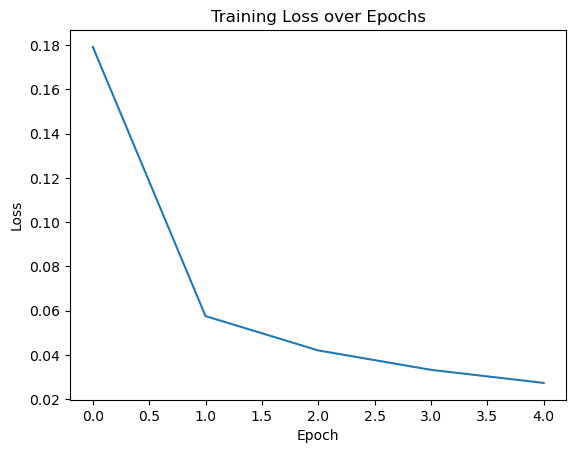

In [3]:
# use CNN to classify MNIST dataset
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import os
os.chdir("D:/workspace/py/dl/stage1")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


class CNNModel(torch.nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, padding=1) # 1 input channel (grayscale), 16 output channels
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, padding=1) # 16 input channels, 32 output channels
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2) # max pooling layer with kernel size 2 and stride 2
        self.linear = torch.nn.Linear(32 * 7 * 7, 10) # fully connected layer to output 10 classes

    def forward(self,x):
        x = torch.relu(self.conv1(x)) # apply first convolutional layer and ReLU activation
        x = self.pool(x) # apply max pooling
        x = torch.relu(self.conv2(x)) # apply second convolutional layer and ReLU activation
        x = self.pool(x) # apply max pooling
        x = x.view(-1, 32 * 7 * 7) # flatten the feature map for the fully connected layer
        x = self.linear(x) # apply the fully connected layer to get the output logits
        return x
    
model = CNNModel()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(epochs):
    loss_list = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")
    return loss_list

def test():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"\n✅ Test Accuracy: {100 * correct / total:.2f}%")

if __name__ == "__main__":
    loss_list = train(5)
    test()
    plt.plot(loss_list)  
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.show()

## 优化方向
1. 可以加Dropout、BatchNorm层：防止过拟合
2. 加深网络，googleNet

Exercise：Try a more complex CNN

Epoch 1/5, Train Loss: 0.1780
Epoch 2/5, Train Loss: 0.0533
Epoch 3/5, Train Loss: 0.0404
Epoch 4/5, Train Loss: 0.0341
Epoch 5/5, Train Loss: 0.0289

✅ Test Accuracy: 98.89%


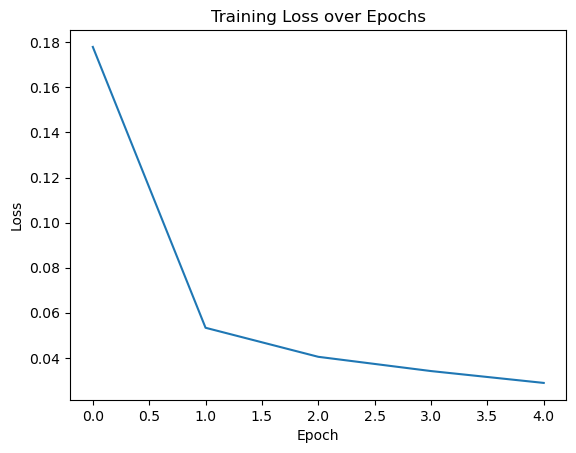

In [4]:
# use complex cnn to classify MNIST dataset
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import os
os.chdir("D:/workspace/py/dl/stage1")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


class CNNModel(torch.nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # 卷积块 1
        self.conv1 = torch.nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(16)  # BN 对应通道数
        self.pool = torch.nn.MaxPool2d(2)

        # 卷积块 2
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(32)

        # 卷积块 3
        self.conv3 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(64)

        # 全连接 + Dropout
        self.linear1 = torch.nn.Linear(64 * 3 * 3, 128)
        self.dropout = torch.nn.Dropout(0.25)  # 丢掉25%
        self.linear2 = torch.nn.Linear(128, 32)
        self.linear3 = torch.nn.Linear(32, 10)

    def forward(self, x):
        # 卷积 + BN + 激活 + 池化
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        # 展平
        x = x.view(-1, 64 * 3 * 3)

        # 全连接 + 激活 + Dropout
        x = torch.relu(self.linear1(x))
        x = self.dropout(x)
        
        x = torch.relu(self.linear2(x))
        x = self.linear3(x)
        return x
    
model = CNNModel()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(epochs):
    loss_list = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")
    return loss_list

def test():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"\n✅ Test Accuracy: {100 * correct / total:.2f}%")

if __name__ == "__main__":
    loss_list = train(5)
    test()
    plt.plot(loss_list)  
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.show()

# googleNet 与 resNet
在GoogleNet出现之前，卷积神经网络（CNN）的性能提升路径相对单一，大多依赖于单纯增加网络的深度与宽度，即不断叠加网络层数、扩充各层神经元数量，以此增强模型的特征提取能力，AlexNet、VGG等经典模型便是这一思路的典型代表。但这种方式存在明显局限，随着层数和单元数的增加，模型的计算量会呈指数级增长，不仅大幅提升了训练成本，还容易出现过拟合、梯度消失等问题，难以实现“深度与效率”的兼顾。在此背景下，GoogleNet应运而生，其作者受Network in Network中1×1卷积核（用于通道融合与维度调整）的启发，结合赫布原则（聚类高度相关的神经元，构建高效稀疏连接），创新性地提出了“Inception”结构——该结构以多个不同尺度的小型密集卷积核（1×1、3×3、5×5）并行计算为核心，搭配池化操作组成基础模块，通过多个Inception模块的有序叠加，最终构成了GoogleNet。该模型的核心优势的是，能够在有效增加神经网络深度、提升特征提取精度的同时，通过1×1卷积降维等设计严控计算复杂度，真正实现了“we need to go deeper”的理念，打破了“深度提升必伴计算量暴涨”的困境。
<p align="center">
    <img src="../img/inception.png" alt="inception">
</p>
在朴素的inception中，是直接使用3×3、5×5卷积核，这会导致输入通道较大，以至于计算爆炸，而在右边这个结构中，是先使用1×1的卷积核将输入通道降维后在卷积。降维后不影响特征吗？第一、低维度的特征嵌入，本质上是对信息的压缩。第二、在降维后再使用3×3、5×5卷积会进一步挖掘和放大保留的核心特征。第三、加入了非线性激活补充了拟合能力。

Epoch 1/5, Train Loss: 0.4787
Epoch 2/5, Train Loss: 0.1305
Epoch 3/5, Train Loss: 0.0882
Epoch 4/5, Train Loss: 0.0675
Epoch 5/5, Train Loss: 0.0532

✅ Test Accuracy: 98.81%


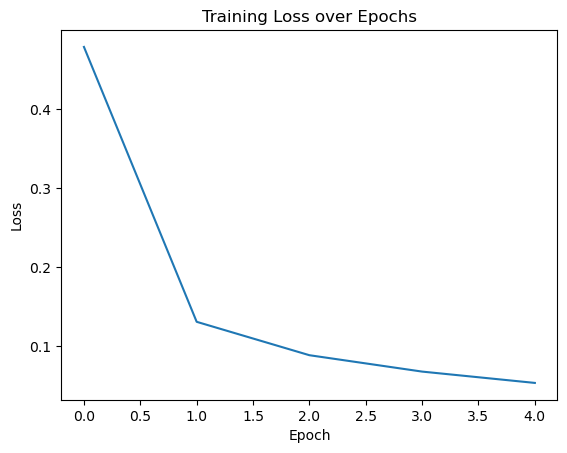

In [ ]:
'''
Author: YhL YhL00004_17@163.com
Date: 2026-04-12 22:41:40
LastEditors: YhL YhL00004_17@163.com
LastEditTime: 2026-04-24 16:15:41
FilePath: \py\dl\stage1\demo1.ipynb
Description: 这是默认设置,请设置`customMade`, 打开koroFileHeader查看配置 进行设置: https://github.com/OBKoro1/koro1FileHeader/wiki/%E9%85%8D%E7%BD%AE
'''
# use inception module to classify MNIST dataset
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class InceptionModule(torch.nn.Module):
    def __init__(self, in_channels):
        super(InceptionModule, self).__init__()
        # 1x1
        self.branch1 = torch.nn.Conv2d(in_channels, 16, kernel_size=1)

        # 1x1 + 3x3
        self.branch2_1 = torch.nn.Conv2d(in_channels, 16, kernel_size=1)
        self.branch2_2 = torch.nn.Conv2d(16, 16, kernel_size=3, padding=1)

        # 1x1 + 5x5
        self.branch3_1 = torch.nn.Conv2d(in_channels, 16, kernel_size=1)
        self.branch3_2 = torch.nn.Conv2d(16, 16, kernel_size=5, padding=2)

        # pool + 1x1
        self.branch4_1 = torch.nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.branch4_2 = torch.nn.Conv2d(in_channels, 16, kernel_size=1)

    def forward(self, x):
        b1 = torch.relu(self.branch1(x))
        b2 = torch.relu(self.branch2_2(torch.relu(self.branch2_1(x))))
        b3 = torch.relu(self.branch3_2(torch.relu(self.branch3_1(x))))
        b4 = torch.relu(self.branch4_2(self.branch4_1(x)))
        return torch.cat([b1, b2, b3, b4], dim=1)  # 16+16+16+16 = 64 通道

class GoogleNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = torch.nn.MaxPool2d(2)

        self.inception1 = InceptionModule(64)   # out: 64
        self.inception2 = InceptionModule(64)   # out: 64

        self.avg_pool = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.linear = torch.nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))

        x = self.inception1(x)
        x = self.inception2(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        return x
model = GoogleNet()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(epochs):
    loss_list = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}")
    return loss_list

def test():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"\n✅ Test Accuracy: {100 * correct / total:.2f}%")

if __name__ == "__main__":
    loss_list = train(5)
    test()
    plt.plot(loss_list)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.show()

In [ ]:
# use resnet module to classify MNIST dataset